In [1]:
# we need to read frames
# so we install opencv-python - change the next cell type to "Code"
# This file is from https://github.com/OpenPIV/openpiv-python-examples/blob/main/notebooks/analyse_movie.ipynb

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from openpiv import pyprocess, validation, filters, piv

In [3]:
# Test it by making another gif from the .nc files, using ~/Box for Hanna-Brian generality
# Since they have no time dimension, we need a trick to open them as a mfdataset

import glob
import os

# Expand the tilde to the home directory
pattern = os.path.expanduser('~/Box/GWaves_2023_10_11-14_SEPAC/VIS/Data/VIS_2023_10_13*')

# Get list of files
files = sorted(glob.glob(pattern))

# Open each file and add a new 'time' coordinate
datasets = [xr.open_dataset(f).assign_coords(time=i) for i, f in enumerate(files)]

# Concatenate along the new 'time' dimension
ds = xr.concat(datasets, dim='time')

ds

<xarray.Dataset> Size: 95MB
Dimensions:    (time: 14, latitude: 1125, longitude: 1500)
Coordinates:
  * latitude   (latitude) float32 4kB 9.94 9.9 9.86 ... -34.94 -34.98 -35.02
  * longitude  (longitude) float32 6kB -129.9 -129.9 -129.9 ... -70.02 -69.98
  * time       (time) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
Data variables:
    Rad        (time, latitude, longitude) float32 94MB nan nan ... 66.74 78.8
Attributes: (12/29)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    production_site:           RBU
    ...                        ...
    date_created:              2023-10-13T14:29:56.1Z
    time_coverage_start:       2023-10-13T14:20:20.9Z
    time_coverage_end:         2023-10-13T14:29:51.8Z
    LUT_Filenames:             SpaceLookParams(FM1A_ADR1270_PR_12_02_01)-7371...
    id:                        68a174cb-b605-43e5-bff6-26cecb9c53c8
    history:                   2024-10-26 06:33:38: Resampled to regular lat-...

In [4]:
dataset1 = xr.open_dataset('~/Box/GWaves_2023_10_11-14_SEPAC/VIS/Data/VIS_2023_10_13_20_15.nc') 
dataset2 = xr.open_dataset('~/Box/GWaves_2023_10_11-14_SEPAC/VIS/Data/VIS_2023_10_13_20_45.nc')

In [5]:
dataarray1 = dataset1.to_array().squeeze()
dataarray2 = dataset2.to_array().squeeze()

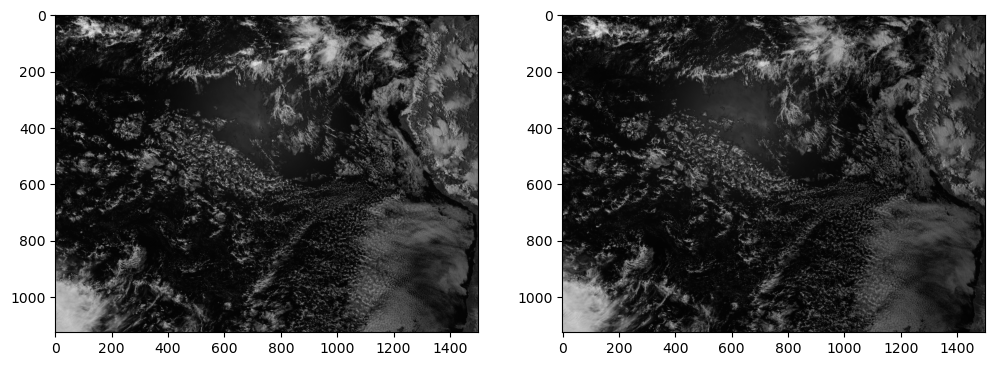

In [6]:
fig,ax = plt.subplots(1,2,figsize=(12,10))
ax[0].imshow(dataarray1,cmap=plt.cm.gray);
ax[1].imshow(dataarray2,cmap=plt.cm.gray);

In [7]:
frame_a = dataarray1.values.astype(np.float32)
frame_b = dataarray2.values.astype(np.float32)

# Optional: normalize for better PIV performance
# frame_a = (frame_a - frame_a.min()) / (frame_a.max() - frame_a.min())
# frame_b = (frame_b - frame_b.min()) / (frame_b.max() - frame_b.min())

In [8]:
window_size = 32
search_size = 32
overlap = 16
dt = 1  # or however long between frames

u, v, sig2noise = pyprocess.extended_search_area_piv(
    frame_a.astype(np.float32),
    frame_b.astype(np.float32),
    window_size=window_size,
    overlap=overlap,
    dt=dt,
    search_area_size=search_size,
    sig2noise_method='peak2peak'
)

In [9]:
print("u range:", np.nanmin(u), np.nanmax(u))
print("v range:", np.nanmin(v), np.nanmax(v))

u range: -14.470149248838425 13.812172770500183
v range: -15.238704815506935 14.33333334326744


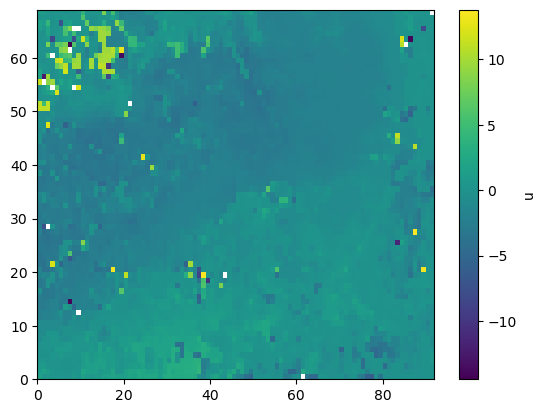

In [10]:
plt.pcolormesh(u)
plt.colorbar(label="u")

In [11]:
x, y = pyprocess.get_coordinates(
    image_size=dataarray1.shape,
    search_area_size=search_size,
    overlap=overlap,)

In [12]:
# To start, lets use the function sig2noise_val to get a mask indicating which vectors have a minimum amount of S2N.
# Vectors below a certain threshold are substituted by NaN. If you are not sure about which threshold value to use,
# try taking a look at the S2N histogram with: plt.hist(sig2noise.flatten())

# invalid_mask = validation.sig2noise_val(
#     sig2noise,
#     threshold = 1.05,)
# invalid_mask = validation.sig2noise_val(
#     u, v, sig2noise,
#     threshold=1.3
# )

In [13]:
# Another useful function is replace_outliers, which will find outlier vectors, and substitute them 
# by an average of neighboring vectors. 
# The larger the kernel_size the larger is the considered neighborhood. 
# This function uses an iterative image inpainting algorithm. The amount of iterations can be chosen via max_iter.


# u2, v2 = filters.replace_outliers(
#     u, v,
#     invalid_mask,
#     method='localmean',
#     max_iter=3,
#     kernel_size=3,)

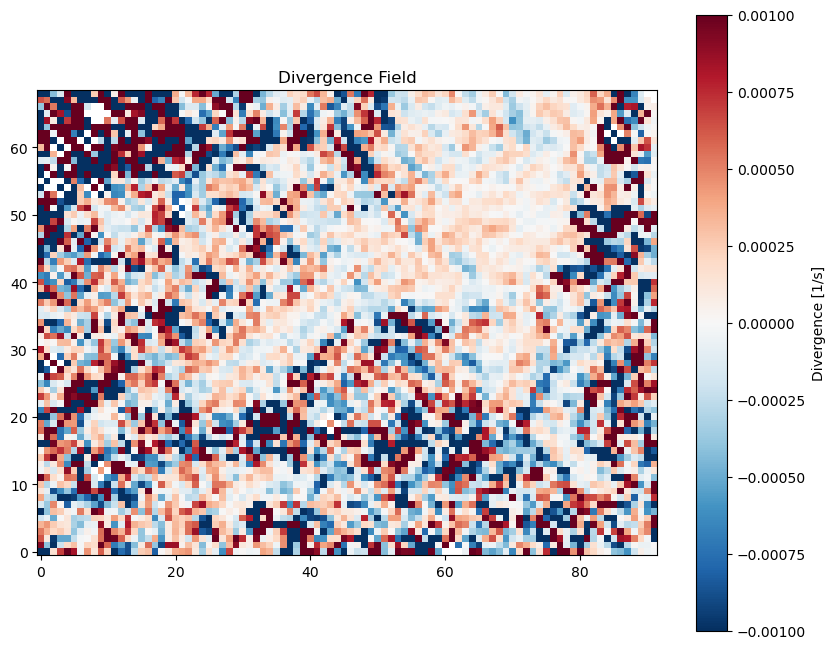

In [14]:
dx = dy = 1000 
divergence = np.gradient(u, dx, axis=1) + np.gradient(v, dy, axis=0)
#divergence_masked = np.where(invalid_mask, np.nan, divergence)
plt.figure(figsize=(10, 8))
plt.imshow(divergence, cmap='RdBu_r', origin='lower', vmin=-.001, vmax=.001)
plt.colorbar(label="Divergence [1/s]")
plt.title("Divergence Field")
plt.show()

Frame difference min/max: 0.0 236.70108


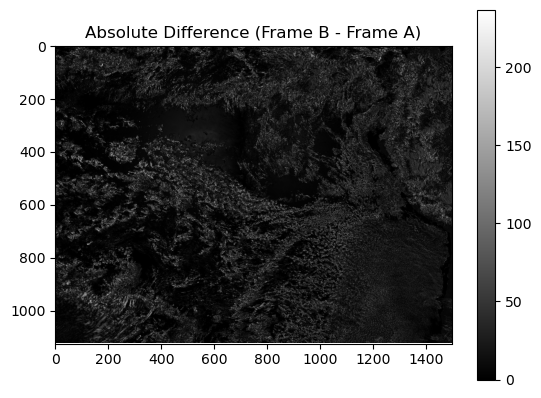

Frame A min/max: -2.237918 304.9458
Frame B min/max: -1.4840927 301.5536


In [15]:
diff = np.abs(frame_b - frame_a)
print("Frame difference min/max:", np.min(diff), np.max(diff))
plt.imshow(diff, cmap='gray')
plt.colorbar()
plt.title("Absolute Difference (Frame B - Frame A)")
plt.show()

print("Frame A min/max:", np.min(frame_a), np.max(frame_a))
print("Frame B min/max:", np.min(frame_b), np.max(frame_b))

Text(0.5, 1.0, 'Raw PIV Velocity Field')

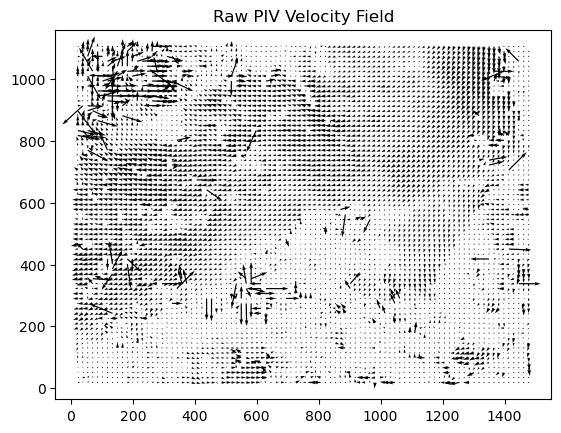

In [16]:
plt.figure()
plt.quiver(x, y, u, v)
plt.title('Raw PIV Velocity Field')

In [17]:
############ FOR DOING A MOVIE ########################

In [18]:
# !pip install opencv-python

In [19]:
import cv2

In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
from openpiv import pyprocess, piv

In [22]:
piv.simple_piv?

Signature: piv.simple_piv(im1, im2, plot=True)
Docstring:
Simplest PIV run on the pair of images using default settings

piv(im1,im2) will create a tmp.vec file with the vector filed in pix/dt
(dt=1) from two images, im1,im2 provided as full path filenames
(TIF is preferable, whatever imageio can read)
File:      ~/Applications/anaconda3/envs/stratocu_waves/lib/python3.13/site-packages/openpiv/piv.py
Type:      function

NameError: name 'image1' is not defined

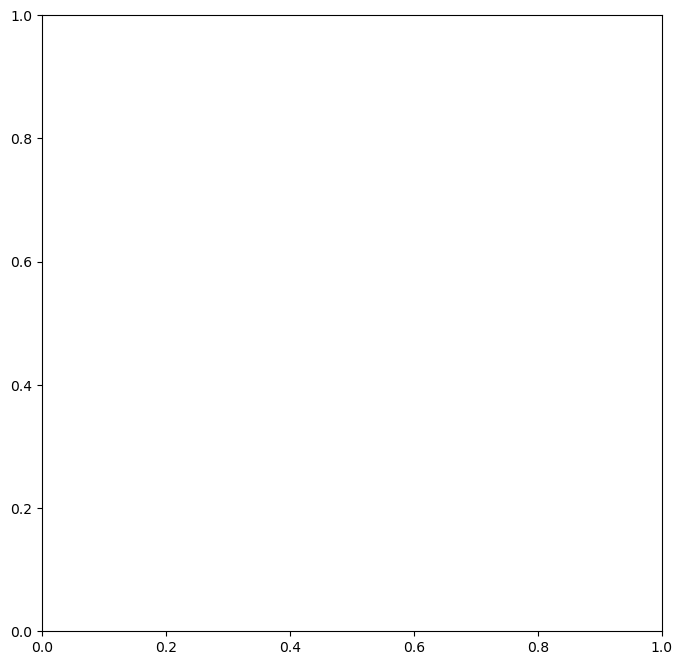

In [23]:
fig,ax = plt.subplots(figsize=(8,8))
ax.imshow(image1,alpha=0.7)
ax.quiver(x,y,Umean,Vmean,scale=300,color='r',width=.008)
# plt.show()
plt.plot(np.mean(Umean,axis=1)*20,y[:,0],color='y',lw=3)